In [73]:
import sys
sys.path.insert(0, "/home/aronw/Development/Clans-3D")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
import Scores_Evaluation.ScoresEvaluator as SE
from InputFileType import InputFileType
from ToolType import ToolType

In [75]:
WORKING_DIR = "/home/aronw/Development/Clans-3D/Scores_Evaluation"
EXAMPLE_DATASET_FASTA = "/home/aronw/Development/Clans-3D/example_files/small_fasta_files/50.fasta"
EXAMPLE_DATASET_TSV = "/home/aronw/Development/Clans-3D/example_files/big_tsv_files/1500.tsv"

In [76]:
evaluator = SE.ScoresEvaluator(WORKING_DIR)

In [ ]:
# Generate clans files from example dataset
clans_files = evaluator.generate_clans_files(EXAMPLE_DATASET_TSV, InputFileType.TSV, ToolType.FOLDSEEK, "evalue")
print(clans_files)

Failed to download https://alphafold.ebi.ac.uk/files/AF-A0A653YI63-F1-model_v6.pdb: HTTPSConnectionPool(host='alphafold.ebi.ac.uk', port=443): Read timed out. (read timeout=10)
Failed to download A0A653YI63 from https://alphafold.ebi.ac.uk/api/prediction/A0A653YI63
Failed to download https://alphafold.ebi.ac.uk/files/AF-W8R7W7-F1-model_v6.pdb: HTTPSConnectionPool(host='alphafold.ebi.ac.uk', port=443): Read timed out.
Failed to download W8R7W7 from https://alphafold.ebi.ac.uk/api/prediction/W8R7W7
Failed to download A0A1S1KSN3 from https://alphafold.ebi.ac.uk/api/prediction/A0A1S1KSN3
Downloaded 1496 from 1499 PDB files successfully.
Computing structural similarity with foldseek...
Structural similarity computation with foldseek completed.
Generating CLANS file f/home/aronw/Development/Clans-3D/Scores_Evaluation/1500_cleaned.clans...
CLANS file generated at /home/aronw/Development/Clans-3D/Scores_Evaluation/1500_cleaned.clans


Building a new DB, current time: 01/26/2026 12:03:42
New DB

In [ ]:
# Parameters for clustering with recovered clans.jar The first entry in each tuple is for structure-based clans, the second for sequence-based clans.
PATH_TO_CLANS_JAR = "/home/aronw/Development/Clans-3D/recovered_CLANS/clans_working_version.jar" # path to clans jar file
CLUSTER_ROUNDS: tuple[int, int] = (10000, 10000) # sets the number of rounds for clustering in recovered clans
P_VALUES: tuple[float, float] = (1E-10, 1E-29) # sets the p-value threshold for clustering in recovered clans for (structure, sequence)
CLUSTER_2D: tuple[bool, bool] = (False, False) # whether to use 2D clustering in recovered clans
VERBOSE: bool = True # whether to print verbose output from recovered clans

In [ ]:
# Cluster the generated clans files
clustered_clans_files = evaluator.cluster_clans_files(PATH_TO_CLANS_JAR, clans_files, CLUSTER_ROUNDS, P_VALUES, CLUSTER_2D, VERBOSE)
print(clustered_clans_files)

In [79]:
import Scores_Evaluation.ScoresEvaluator as SE
evaluator = SE.ScoresEvaluator(WORKING_DIR)
clustered_clans_files = ("/home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans",
                         "/home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans")

In [81]:
# Extract data from clustered CLANS files
df_scores, df_euclidean_dist, df_coord = evaluator.extract_data_from_clans_files(clustered_clans_files)
print(df_scores.head())
print(df_euclidean_dist.head())
print(df_coord.head())


Evaluating clustered clans files: /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans and /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_clustered_r_10000_p_1e-10.clans...
Parsing CLANS file /home/aronw/Development/Clans-3D/Scores_Evaluation/500_cleaned_seq_clustered_r_10000_p_1e-29.clans...
  Sequence_ID_1 Sequence_ID_2  Score_struct  Score_-log10_struct  \
0    A0A010TDP2    A0A0C5ERJ6  6.898000e-11            10.161277   
1    A0A010TDP2    A0A0D5XUC7  6.622000e-11            10.179011   
2    A0A010TDP2    A0A0D6SYC0  1.373000e-10             9.862329   
3    A0A010TDP2    A0A0F4VEF5  6.622000e-11            10.179011   
4    A0A010TDP2    A0A0J6GDG7  6.898000e-11            10.161277   

      Score_seq  Score_-log10_seq  
0  1.270000e-49         48.896196  
1  1.270000e-49         48.896196  
2  1.290000e

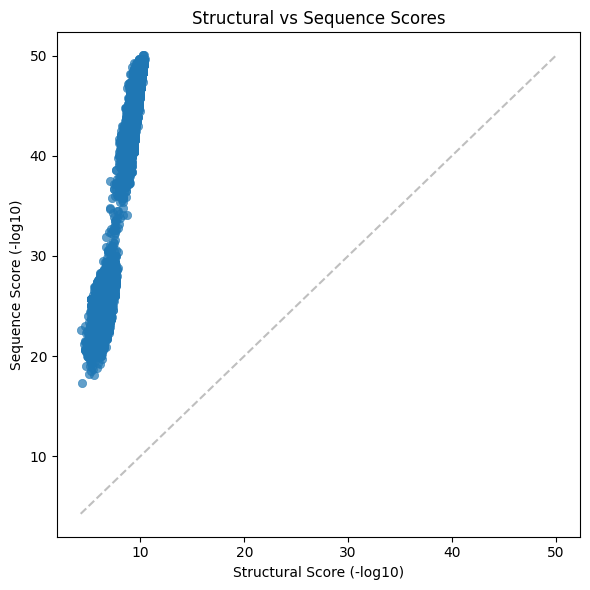

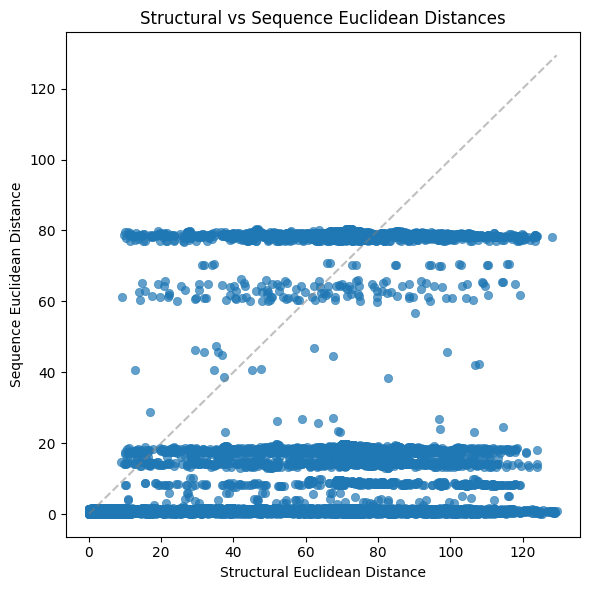

In [ ]:
# Generate scatter plots to visualize relationships between scores and euclidian-distances
evaluator.visualizer.generate_scatter_plot(
    data_x=df_scores["Score_-log10_struct"],
    data_y=df_scores["Score_-log10_seq"],
    x_label="Structural Score (-log10)",
    y_label="Sequence Score (-log10)",
    title="Structural vs Sequence Scores"
)

evaluator.visualizer.generate_scatter_plot(
    data_x=df_euclidean_dist["euclidean_dist_struct"],
    data_y=df_euclidean_dist["euclidean_dist_seq"],
    x_label="Structural Euclidean Distance",
    y_label="Sequence Euclidean Distance",
    title="Structural vs Sequence Euclidean Distances"
)

In [82]:
# Find clusters using density-based and graph-based methods
RESOLUTION_PARAMS = (1.007, 1.01)  # (structure, sequence)
df_cluster_labels = evaluator.clustering.find_clusters_density_based(df_coord, "struct")
df_cluster_labels = df_cluster_labels.merge(evaluator.clustering.find_clusters_density_based(df_coord, "seq"), on="Sequence_ID")
df_Leiden_labels = evaluator.clustering.find_clusters_graph_based(df_scores, "Score_-log10_struct", resolution=RESOLUTION_PARAMS[0])
df_Leiden_labels = df_Leiden_labels.merge(evaluator.clustering.find_clusters_graph_based(df_scores, "Score_-log10_seq", resolution=RESOLUTION_PARAMS[1]), on="Sequence_ID")
df_cluster_labels = df_cluster_labels.merge(df_Leiden_labels, on="Sequence_ID")
df_cluster_labels

,Sequence_ID,cluster_id_struct_HDBSCAN,cluster_id_seq_HDBSCAN,cluster_id_Score_-log10_struct_Leiden,cluster_id_Score_-log10_seq_Leiden
0,A0A010TDP2,5,2,0,0
1,A0A023WWI9,1,2,1,1
2,A0A024EET1,5,2,0,0
3,A0A024HPB1,5,2,3,2
4,A0A031G2U6,5,2,0,0
...,...,...,...,...,...
488,V9V7Z7,5,2,0,0
489,W6QRK7,-1,2,1,1
490,W6VLX3,5,2,0,0
491,W7QD92,3,1,1,1


In [83]:
labels_struct_HDBSCAN = df_cluster_labels["cluster_id_struct_HDBSCAN"].drop_duplicates()
len(labels_struct_HDBSCAN)
labels_seq_HDBSCAN = df_cluster_labels["cluster_id_seq_HDBSCAN"].drop_duplicates()
len(labels_seq_HDBSCAN)

labels_struct_Leiden = df_cluster_labels["cluster_id_Score_-log10_struct_Leiden"].drop_duplicates()
len(labels_struct_Leiden)
labels_seq_Leiden = df_cluster_labels["cluster_id_Score_-log10_seq_Leiden"].drop_duplicates()
len(labels_seq_Leiden)

# expected number of clusters in clans file struct visually 4 - 5
# expected number of clusters in clans file seq visually 3
print(f"Number of clusters (HDBSCAN - structure): {len(labels_struct_HDBSCAN)}") 
print(f"Number of clusters (HDBSCAN - sequence): {len(labels_seq_HDBSCAN)}")
print(f"Number of clusters (Leiden - structure): {len(labels_struct_Leiden)}")
print(f"Number of clusters (Leiden - sequence): {len(labels_seq_Leiden)}")

Number of clusters (HDBSCAN - structure): 7
Number of clusters (HDBSCAN - sequence): 3
Number of clusters (Leiden - structure): 5
Number of clusters (Leiden - sequence): 3


In [84]:
clustering_agreement_HDBSCAN = evaluator.clustering.compute_clustering_agreement(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN")
clustering_agreement_Leiden = evaluator.clustering.compute_clustering_agreement(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden")
print(f"Clustering agreement (HDBSCAN): {clustering_agreement_HDBSCAN}")
print(f"Clustering agreement (Leiden): {clustering_agreement_Leiden}")

Clustering agreement (HDBSCAN): {'ARI': 0.11020085935923137, 'NMI': 0.135652397555988}
Clustering agreement (Leiden): {'ARI': 0.9679424999000981, 'NMI': 0.9362835568848873}


In [86]:
jaccard_results_HDBSCAN = evaluator.clustering.compute_Jaccard_overlap(df_cluster_labels, "cluster_id_struct_HDBSCAN", "cluster_id_seq_HDBSCAN", remove_zero_jaccard=True)
jaccard_results_Leiden = evaluator.clustering.compute_Jaccard_overlap(df_cluster_labels, "cluster_id_Score_-log10_struct_Leiden", "cluster_id_Score_-log10_seq_Leiden", remove_zero_jaccard=True)
print("Jaccard Overlap Results (HDBSCAN - structure vs sequence):")
print(jaccard_results_HDBSCAN)
print("Jaccard Overlap Results (Leiden - structure vs sequence):")
print(jaccard_results_Leiden)


Jaccard Overlap Results (HDBSCAN - structure vs sequence):
   cluster_id_struct_HDBSCAN  cluster_id_seq_HDBSCAN  JaccardIndex
0                          0                       2      0.075688
1                          1                       2      0.064220
2                          2                       2      0.029817
3                          3                       0      0.084507
4                          3                       1      0.211268
5                          3                       2      0.109409
6                          4                       2      0.034404
7                          5                       2      0.681193
Jaccard Overlap Results (Leiden - structure vs sequence):
   cluster_id_Score_-log10_struct_Leiden  cluster_id_Score_-log10_seq_Leiden  \
0                                      0                                   0   
1                                      1                                   1   
2                                      2